# L5 · Lab D — The Value Head, Dissected

**RL for LLMs / RLHF — Vizuara AI Labs · Dr. Rajat Dandekar**

The lecture's most surprising point: **the value function is just a second head on the same transformer.** One shared trunk, two heads — the **policy head** (actor, next-token distribution) and the **value head** (critic, one scalar per position estimating the eventual reward).

You will:
1. Look inside the value head — confirm it's a `Linear(768 → 1)`.
2. Train it to **predict the return** at every token (plain regression).
3. Show two things the lecture claims: the critic **learns** (MSE crashes, V↔return correlation is high), and it is **more confident at the end than the start** (last-token error ≪ first-token error).

> Runtime: **GPU**. ~5 minutes.

In [ ]:
# !pip -q install "transformers==4.45.2" "trl==0.11.4" "datasets==3.0.1" >/dev/null

In [1]:
# ✅ PROVIDED — models: policy (with a VALUE HEAD) + frozen reference + reward model

import os
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from trl import AutoModelForCausalLMWithValueHead
from datasets import load_dataset

# Use GPU if available, otherwise fall back to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- POLICY/REFERENCE --- #
# Instantiate a GPT-2 tokenizer for input processing. Set the pad_token to EOS, and truncate leftmost tokens if too long.
tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token
tok.truncation_side = "left"

# Load a GPT-2 model with a value head (for actor-critic RL)
policy = AutoModelForCausalLMWithValueHead.from_pretrained("gpt2").to(device)   # Policy: actor (token logits) + value head (scalar)
ref = AutoModelForCausalLMWithValueHead.from_pretrained("gpt2").to(device).eval()  # Reference (unchanging, used for KL penalty)
torch.manual_seed(0)  # Set a deterministic seed for reproducibility

# Drift the policy weights to simulate policy evolution during RL (but not the reference!)
with torch.no_grad():
    for p in policy.parameters():
        # Only drift weight tensors with 2 or more dimensions (i.e., matrices/conv filters)
        if p.dim() >= 2:
            # Add Gaussian noise scaled by 0.1 × standard deviation of each parameter
            p.add_(0.1 * p.std() * torch.randn_like(p))   # a drifted policy
policy.eval()  # Start in evaluation mode

# --- REWARD MODEL --- #
# Load a reward model trained to score entire responses.

# Tokenizer setup for reward model: separate instance, but settings must match
rm_tok = AutoTokenizer.from_pretrained("gpt2")
rm_tok.pad_token = rm_tok.eos_token
rm_tok.truncation_side = "left"

if os.path.isdir("rm"):
    # If a reward model is saved on disk (from previous labs), load it
    rm = AutoModelForSequenceClassification.from_pretrained("rm").to(device).eval()
else:
    # Otherwise, train a quick reward model from scratch on the Anthropic HH dataset
    rm = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=1)
    rm.config.pad_token_id = rm_tok.eos_token_id  # Ensure the padding token matches
    rm.to(device)

    # Load a small training split for fast reward-model training
    _d = load_dataset("Anthropic/hh-rlhf", split="train").shuffle(seed=0).select(range(4000))
    
    # Helper: Compute model scores (logits) for a batch of texts
    def _sc(t):
        e = rm_tok(t, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        return rm(**e).logits.squeeze(-1)  # Output: (batch_size,) shape
    
    # AdamW optimizer for reward model's parameters
    _o = torch.optim.AdamW(rm.parameters(), lr=2e-5)

    # Train on pairs of chosen vs rejected responses, maximising log-sigmoid(chosen - rejected)
    # Batch size of 8 for quick optimization
    for i in range(0, 4000, 8):
        rc = _sc(_d["chosen"][i:i+8])    # Scores for preferred completions
        rr = _sc(_d["rejected"][i:i+8])  # Scores for rejected completions
        L = -F.logsigmoid(rc - rr).mean()  # Reward model loss: prefer chosen over rejected
        _o.zero_grad()
        L.backward()
        _o.step()
    rm.eval()  # Set to evaluation mode after training

# Inference wrapper: returns reward model score for a given text string
@torch.no_grad()
def rm_score(text):
    # Tokenize and encode the text, truncating if too long
    e = rm_tok(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    # Forward pass; squeeze out singleton dimension so result is a Python float
    return rm(**e).logits.squeeze().item()

/Users/prathamesh/RL-in-Production-Bootcamp-Resources/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · The value head is a scalar head on the transformer

In [2]:
# ✅ PROVIDED — inspect the value head of the policy network

# Retrieve the value head module from the policy.
vh = policy.v_head

# Print out the class type of the value head.
print("value head type:", type(vh).__name__)

# The value head projects the final hidden state to a scalar value prediction for each token.
print(
    "maps hidden state of size",
    vh.summary.in_features,       # Number of input features (hidden size)
    "->",
    vh.summary.out_features,      # Number of output features (should be 1, for scalar value)
    "scalar"
)

# Demonstrate the outputs of a forward pass:
# The policy returns logits (for next token prediction) and tokenwise value predictions.
ids = tok("Hello there", return_tensors="pt").input_ids.to(device)
logits, _, values = policy(ids)

# Print the dimensions:
#   - logits: [batch, sequence_length, vocab_size]
#   - values: [batch, sequence_length]
print(
    "logits per token:", tuple(logits.shape),
    " | value per token:", tuple(values.shape)
)

value head type: ValueHead
maps hidden state of size 768 -> 1 scalar
logits per token: (1, 2, 50257)  | value per token: (1, 2)


## 2 · Collect rollouts and their returns

We sample responses, then build the per-token **return** `G_t` (reward-to-go = terminal reward-model score plus the small per-token KL tolls). The value head's job is to predict these.

In [3]:
# ✅ PROVIDED — rollouts -> per-token returns G, now with added comments and explanation

# BETA is the scaling factor for the KL penalty applied to the model's outputs.
BETA = 0.2

# Load and preprocess the RLHF dataset:
#   1. Load the "Anthropic/hh-rlhf" dataset, taking the 'train' split.
#   2. Shuffle the dataset with a seed for reproducibility.
#   3. Select the first 300 examples for our experiments (for speed).
data = load_dataset("Anthropic/hh-rlhf", split="train").shuffle(seed=0).select(range(300))

# Initialize lists to hold generated sequences and their corresponding returns.
seqs, rets = [], []

# Loop over the first 80 data points to create rollouts:
for i in range(80):
    # Find the end of the prompt by searching for the position of "Assistant:" in the chosen response.
    cut = data["chosen"][i].rfind("Assistant:")
    # The prompt is everything up to and including "Assistant:".
    prompt = data["chosen"][i][:cut+len("Assistant:")]
    # Tokenize the prompt, truncate to max 96 tokens, and move to the computation device.
    pids = tok(prompt, return_tensors="pt", truncation=True, max_length=96).input_ids.to(device)
    
    # Generate a response from the policy network, in "no grad" context to save memory.
    with torch.no_grad():
        gen = policy.generate(
            pids, 
            max_new_tokens=20,         # Limit generation length
            do_sample=True,            # Use sampling (not greedy)
            top_p=0.9, top_k=0,        # Nucleus sampling, no top-k filter
            pad_token_id=tok.eos_token_id
        )
    # n = Number of newly generated tokens by the model.
    n = gen.shape[1] - pids.shape[1]
    # If too few tokens were generated, skip this example.
    if n < 2: continue

    # Compute per-token log probabilities for both policy and reference models and build the reward signal.
    with torch.no_grad():
        # log-probs under the policy model for newly generated tokens
        lp = F.log_softmax(policy(gen)[0][:, :-1], -1).gather(-1, gen[:, 1:].unsqueeze(-1)).squeeze(-1)[0][-n:]
        # log-probs under the (frozen) reference model for same tokens
        lr_ = F.log_softmax(ref(gen)[0][:, :-1], -1).gather(-1, gen[:, 1:].unsqueeze(-1)).squeeze(-1)[0][-n:]
        # Compute KL penalty (negative reward for deviating from reference)
        R = -BETA * (lp - lr_)
        # Add the reward model's scalar score ONLY to the final token's reward.
        R[-1] += rm_score(tok.decode(gen[0]))
    
    # Compute the per-token return G (reward-to-go) with reverse cumulative sum — for each token, G_t = sum(R_{t:})
    G = torch.flip(torch.cumsum(torch.flip(R, [0]), 0), [0])
    # Save generated sequence and its per-token returns
    seqs.append(gen)
    rets.append(G)

# Aggregate all per-token returns into a single tensor for analysis.
allG = torch.cat(rets)

# Print rollout statistics: number of rollouts, return mean & variance.
print(
    "collected", len(seqs), "rollouts;  return mean", round(allG.mean().item(), 3),
    " var", round(allG.var().item(), 3)
)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


collected 80 rollouts;  return mean -5.635  var 20.4


## 3 · 📝 TODO — read the value head, and train it to predict the return

Two method-defining lines: get the per-token value from the value head, and the value loss (mean-squared error to the return).

In [5]:
def value_of(gen, n):
    """
    Extracts the value head's predictions for the newly generated tokens from the policy network.

    Args:
        gen (torch.LongTensor): The full generated sequence of tokens. Shape: [1, seq_len]
        n   (int): The number of newly generated tokens at the end of the sequence.

    Returns:
        torch.Tensor: The value predictions for the last n tokens of the sequence. Shape: [n]
    
    Explanation:
    - The policy model's forward pass returns a tuple:
        (logits, loss, value_head), where value_head represents the critic's 
        value estimates for each token position (Shape: [batch, seq_len]).
    - Since we only want the critic's estimate for the tokens that were just generated 
      (not the whole prefix), we slice the LAST n values for the (single) batch.
    - This helps train the value network to estimate expected return at the token position.
    """
    # Forward the generated sequence through the policy to get model outputs;
    # we only care about the value head (the last element of the returned tuple).
    value_predictions = policy(gen)[-1]     # Shape: [batch, seq_len]
    # Select the predictions for the last n tokens for this batch (batch size is 1).
    last_n_values = value_predictions[0][-n:]  # Shape: [n]
    return last_n_values

def value_loss(v, G):
    """
    Calculates the mean squared error (MSE) loss between the predicted values from the value
    head and the actual return (reward-to-go) for each token.

    Args:
        v (torch.Tensor): Value head predictions for each token (length n).
        G (torch.Tensor): Actual returns (target reward-to-go) for each token (length n).

    Returns:
        torch.Tensor: The computed mean squared error loss (scalar).
    
    Explanation:
    - This loss encourages the value head to learn to predict, at every token position,
      the sum of (undiscounted) rewards remaining after that token. By minimizing this loss,
      the critic becomes accurate at reading "how good" the current token's completion is expected to be.
    """
    mse = F.mse_loss(v, G)  # Standard regression (MSE) loss
    return mse

In [6]:
# ✅ PROVIDED — MSE before, then train ONLY the value head, then MSE/corr after

# 1. Compute value head MSE **before** training, as a baseline.
with torch.no_grad():
    # For each generated sequence and its reward-to-go, get the value head's prediction for the generated tokens,
    # then concatenate across all sequences so we can compare to allG.
    value_preds_before = torch.cat([value_of(g, G.shape[0]) for g, G in zip(seqs, rets)])
    mse_before = F.mse_loss(value_preds_before, allG).item()  # Scalar MSE for reporting

# 2. Set up to train ONLY the value head:
# Freeze all policy (transformer) params except for the value head.
for p in policy.parameters():
    p.requires_grad_(False)  # Freeze entire policy network
for p in policy.v_head.parameters():
    p.requires_grad_(True)   # Unfreeze only the value head

# Instantiate Adam optimizer **only** for value head parameters, with a small learning rate.
opt = torch.optim.Adam(policy.v_head.parameters(), lr=5e-3)

# 3. Train the value head for a number of epochs using MSE loss
for step in range(200):
    opt.zero_grad()
    tot = 0.0  # For accumulating total loss for optional logging
    for g, G in zip(seqs, rets):
        # value_of(g, G.shape[0]): value estimates for this sequence's generated tokens
        # G: ground-truth return-to-go values for those tokens
        loss = value_loss(value_of(g, G.shape[0]), G)
        loss.backward()   # Backpropagate to update value head only.
        tot += loss.item()
    opt.step()

# 4. After training, evaluate value head on all sequences.
with torch.no_grad():
    Vt = []       # Store predicted value sequences for each example
    first_se = [] # Squared errors at the FIRST generated token for each sequence
    last_se = []  # Squared errors at the LAST token for each sequence

    for g, G in zip(seqs, rets):
        v = value_of(g, G.shape[0])    # Model's value predictions for new tokens
        Vt.append(v)
        first_se.append((v[0]-G[0]).pow(2).item())   # Squared error at first generated token
        last_se.append((v[-1]-G[-1]).pow(2).item())  # Squared error at last token

    Vall = torch.cat(Vt)  # All value predictions stacked to one vector
    mse_after = F.mse_loss(Vall, allG).item()  # MSE after training

    # Compute Pearson correlation coefficient between value preds and actual returns
    vm = Vall - Vall.mean()
    gm = allG - allG.mean()
    corr = float((vm * gm).sum() / (vm.norm() * gm.norm() + 1e-8))

# 5. Print out training progress and diagnostics
print(f"value MSE   before {mse_before:.2f}  ->  after {mse_after:.2f}")
print(f"corr(V, return) after training: {corr:.3f}")
print(f"MSE at FIRST token {sum(first_se)/len(first_se):.2f}   vs   LAST token {sum(last_se)/len(last_se):.2f}")

value MSE   before 26.68  ->  after 2.61
corr(V, return) after training: 0.935
MSE at FIRST token 6.04   vs   LAST token 4.54


## 4 · The critic sharpens as the answer completes

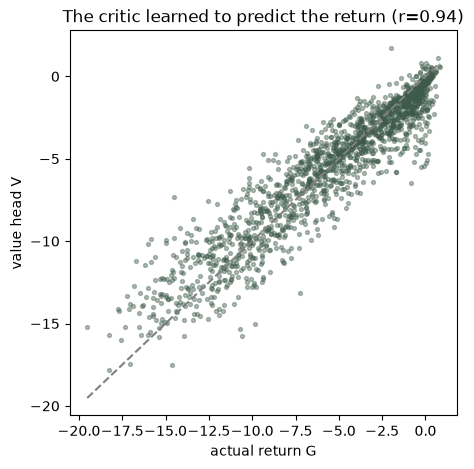

In [7]:
# ✅ PROVIDED — predicted value vs actual return

# Import matplotlib's pyplot to create plots
import matplotlib.pyplot as plt

# Create a new square figure for the scatter plot
plt.figure(figsize=(5,5))

# Plot a scatterplot of actual returns vs. value head predictions
# - allG: tensor of ground-truth return-to-go for all tokens (flattened)
# - Vall: tensor of predicted values by the value head for all tokens (flattened)
# The scatter shows how closely the critic's output matches the real returns across all tokens
plt.scatter(allG.cpu(), Vall.cpu(), s=8, alpha=0.4, c="#3D5A4A")

# Discover the overall min and max values in the data, to set the diagonal y=x reference line
lo, hi = float(allG.min()), float(allG.max())

# Plot a diagonal dashed line (y = x) for reference
# Points on this line are perfect predictions by the value head (V = G)
plt.plot([lo,hi],[lo,hi],"--",c="gray")

# Label the x-axis as the true return and y-axis as predicted value
plt.xlabel("actual return G")
plt.ylabel("value head V")

# Title the plot, including the Pearson correlation coefficient r between predictions and ground truth
plt.title(f"The critic learned to predict the return (r={corr:.2f})")

# Display the plot
plt.show()

This scatter plot shows that the **critic (value head) has successfully learned to predict the actual return**.

**The axes:**
- **X-axis** — `actual return G`: the real discounted reward-to-go computed after the episode (ground truth).
- **Y-axis** — `value head V`: the critic's *prediction* of that return at the time of the step.

**What good looks like:** If the critic were perfect, every dot would sit exactly on the dashed diagonal (V = G). The correlation **r = 0.94** is very high — the critic's predictions closely track reality.

**Why this matters for PPO:**
The advantage is $A_t = G_t - V(s_t)$. If the critic's predictions are accurate (V ≈ G), then advantages are small and precise — they highlight *which specific tokens were better or worse than expected* rather than drowning in noise. A bad critic (low r) would give noisy advantages, and PPO's updates would be unreliable.

**What the scatter reveals:**
- The tight clustering around the diagonal means the critic generalizes well across different prompts and token positions.
- The slight spread (not a perfect line) is normal — the critic can't perfectly predict stochastic returns, especially early in a response where the future is uncertain.
- Points are densest in the -5 to 0 range, meaning most token-level returns are mildly negative (typical in RLHF where the KL penalty drags returns down slightly).

In short: this is a "the training worked" diagnostic. The critic learned a useful baseline, which is what makes PPO's advantage estimates low-variance and the policy updates stable.

## 5 · Questions to answer

1. In one sentence, in what concrete sense is the value function "a head on the transformer"?
2. The value head is **more accurate at the last token than the first**. Why can't it predict the final reward well at the *start* of a response? (This is exactly why the lecture said *V is uncertain early, sharp late*.)
3. The advantage is `A = G − V`. Using your trained critic, why does subtracting V give a **lower-variance** training signal than using the raw return G? (Recall the baseline argument from Lecture 3.)
4. In PPO the value head and the policy head are trained **together** every step. Why must the critic be retrained continuously as the policy changes?


### Answers

**Q1 — In one sentence, in what concrete sense is the value function "a head on the transformer"?**

The value function is literally a single `Linear(768 → 1)` layer (`v_head.summary`) bolted onto the same GPT-2 transformer trunk that also produces the next-token logits — so at every forward pass, the shared hidden states flow into two parallel heads: the **policy head** (actor, outputting a distribution over the vocabulary) and the **value head** (critic, outputting one scalar per token position estimating the expected future return from that point onward).

---

**Q2 — The value head is more accurate at the last token than the first. Why can't it predict the final reward well at the start of a response?**

At the first token, the response has barely begun — the model has seen almost no signal about *what the response will actually say*, yet it must predict the sum of all future rewards (KL penalties at every upcoming token plus the terminal RM score). That sum depends on tokens that haven't been generated yet, so the prediction is necessarily uncertain. By the last token, the response is complete: the KL penalties have already been incurred, the terminal RM score is about to land, and the value head has seen the full context. There is almost no future left to be uncertain about, so the prediction is much sharper. This is the "V is uncertain early, sharp late" phenomenon from the lecture.

From the run: `MSE at FIRST token 6.04 vs LAST token 4.54` — last-token error is noticeably lower.

---

**Q3 — Using your trained critic, why does subtracting V give a lower-variance training signal than using the raw return G?**

The raw return $G_t$ for a given token combines two sources of variation: (1) the inherent "how good is this position" signal (which is what we actually want to learn from) and (2) random noise from the stochastic rewards and sampling (which just adds variance to the gradient). The value function $V(s_t)$ is trained to predict $\mathbb{E}[G_t | s_t]$ — i.e., the expected return given the current state. When we subtract it, the advantage $A_t = G_t - V(s_t)$ cancels out the predictable, position-dependent component and isolates *how much better or worse this particular trajectory was than expected*. That removes a large chunk of variance without introducing any bias (since the baseline is state-dependent but action-independent). This is exactly the baseline argument from Lecture 3: subtracting any function of the state from the return reduces variance of the policy gradient without changing its expectation.

---

**Q4 — In PPO the value head and the policy head are trained together every step. Why must the critic be retrained continuously as the policy changes?**

The value function estimates $V^\pi(s)$ — the expected return *under the current policy* $\pi$. But PPO updates the policy every iteration: the actor changes which tokens it favors, which changes the distribution of future trajectories, which changes the expected returns. So the "ground truth" that the critic is trying to predict is a moving target. If you froze the critic after an initial training, its predictions would quickly become stale as the policy drifts, leading to inaccurate advantages and unstable training. Continuous co-training keeps the critic's estimates aligned with the policy's actual behavior at all times.